In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Connect to the database
DB_PATH = r"C:\Users\ganga\Documents\Data Engineer\DE Projects\marketing_funnel\marketing-funnel-etl\data\marketing_funnel.db"
conn = sqlite3.connect(DB_PATH)

# Set chart style
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False

print("Connected to database successfully.")

Connected to database successfully.


In [2]:
funnel_df = pd.read_sql(
    "SELECT * FROM mart_funnel_metrics ORDER BY total_revenue DESC",
    conn
)

roi_df = pd.read_sql(
    "SELECT * FROM mart_channel_roi ORDER BY roas DESC",
    conn
)

print("Funnel metrics:")
print(funnel_df[["channel","total_leads","total_customers",
                  "lead_to_customer_pct","total_revenue"]].to_string(index=False))
print("\nChannel ROI:")
print(roi_df[["channel","total_spend_usd","total_revenue","roas"]].to_string(index=False))

Funnel metrics:
   channel  total_leads  total_customers  lead_to_customer_pct  total_revenue
   organic         1067               94                  8.81     2282655.63
  meta ads          950               93                  9.79     2255776.24
     email          987               74                  7.50     2050516.29
  referral         1018               66                  6.48     1656632.77
google ads          978               57                  5.83     1480593.13

Channel ROI:
   channel  total_spend_usd  total_revenue  roas
  meta ads        240019.05     2255776.24  9.40
   organic        257114.75     2282655.63  8.88
     email        302190.16     2050516.29  6.79
  referral        246842.92     1656632.77  6.71
google ads        289437.18     1480593.13  5.12


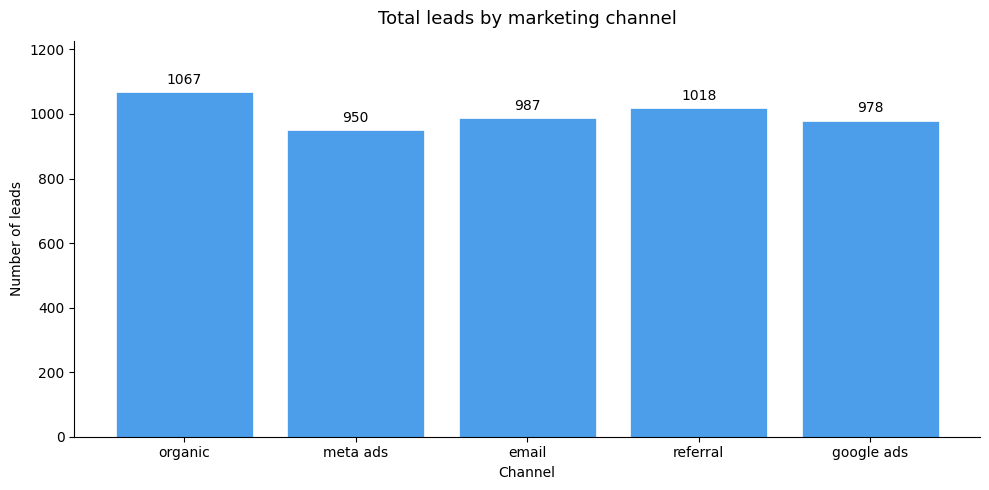

Saved → docs/chart_leads_by_channel.png


In [3]:
fig, ax = plt.subplots()

bars = ax.bar(
    funnel_df["channel"],
    funnel_df["total_leads"],
    color="#4C9EEB",
    edgecolor="white",
    linewidth=0.5
)

ax.bar_label(bars, padding=4, fontsize=10)
ax.set_title("Total leads by marketing channel", fontsize=13, pad=12)
ax.set_xlabel("Channel")
ax.set_ylabel("Number of leads")
ax.set_ylim(0, funnel_df["total_leads"].max() * 1.15)

plt.tight_layout()
plt.savefig("../docs/chart_leads_by_channel.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → docs/chart_leads_by_channel.png")

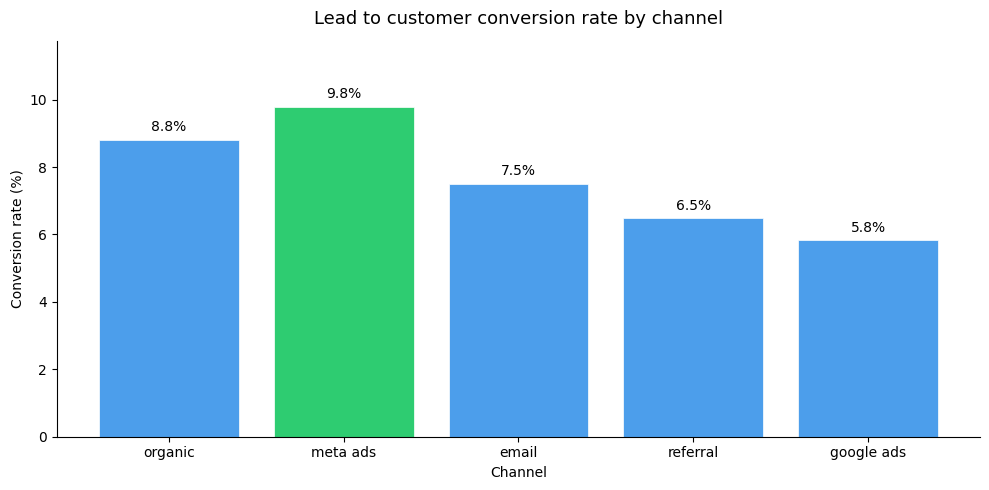

Saved → docs/chart_conversion_rate.png


In [4]:
fig, ax = plt.subplots()

colors = ["#2ECC71" if x == funnel_df["lead_to_customer_pct"].max()
          else "#4C9EEB" for x in funnel_df["lead_to_customer_pct"]]

bars = ax.bar(
    funnel_df["channel"],
    funnel_df["lead_to_customer_pct"],
    color=colors,
    edgecolor="white",
    linewidth=0.5
)

ax.bar_label(bars, fmt="%.1f%%", padding=4, fontsize=10)
ax.set_title("Lead to customer conversion rate by channel", fontsize=13, pad=12)
ax.set_xlabel("Channel")
ax.set_ylabel("Conversion rate (%)")
ax.set_ylim(0, funnel_df["lead_to_customer_pct"].max() * 1.2)

plt.tight_layout()
plt.savefig("../docs/chart_conversion_rate.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → docs/chart_conversion_rate.png")

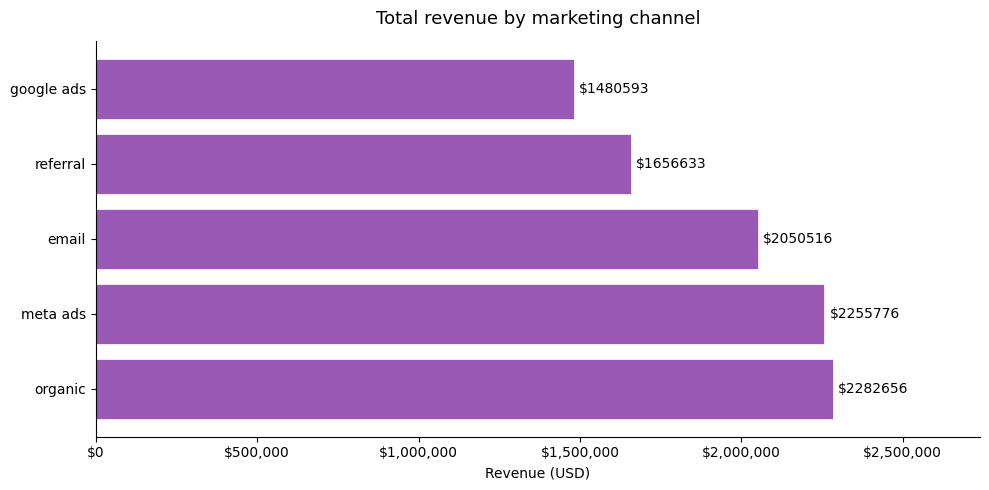

Saved → docs/chart_revenue_by_channel.png


In [5]:
fig, ax = plt.subplots()

bars = ax.barh(
    funnel_df["channel"],
    funnel_df["total_revenue"],
    color="#9B59B6",
    edgecolor="white",
    linewidth=0.5
)

ax.bar_label(bars, fmt="$%.0f", padding=4, fontsize=10)
ax.set_title("Total revenue by marketing channel", fontsize=13, pad=12)
ax.set_xlabel("Revenue (USD)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"${x:,.0f}"
))
ax.set_xlim(0, funnel_df["total_revenue"].max() * 1.2)

plt.tight_layout()
plt.savefig("../docs/chart_revenue_by_channel.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → docs/chart_revenue_by_channel.png")

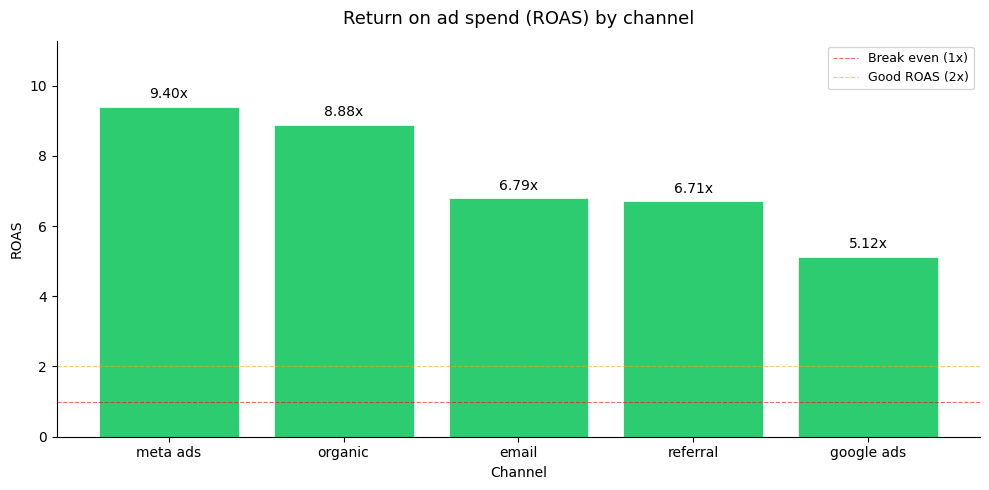

Saved → docs/chart_roas.png


In [6]:
fig, ax = plt.subplots()

colors = ["#E74C3C" if x < 1.0
          else "#F39C12" if x < 2.0
          else "#2ECC71"
          for x in roi_df["roas"]]

bars = ax.bar(
    roi_df["channel"],
    roi_df["roas"],
    color=colors,
    edgecolor="white",
    linewidth=0.5
)

ax.bar_label(bars, fmt="%.2fx", padding=4, fontsize=10)
ax.axhline(y=1.0, color="red",   linestyle="--", linewidth=0.8, alpha=0.6, label="Break even (1x)")
ax.axhline(y=2.0, color="orange",linestyle="--", linewidth=0.8, alpha=0.6, label="Good ROAS (2x)")
ax.set_title("Return on ad spend (ROAS) by channel", fontsize=13, pad=12)
ax.set_xlabel("Channel")
ax.set_ylabel("ROAS")
ax.legend(fontsize=9)
ax.set_ylim(0, roi_df["roas"].max() * 1.2)

plt.tight_layout()
plt.savefig("../docs/chart_roas.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → docs/chart_roas.png")

In [7]:
conn.close()
print("Analysis complete.")
print("Charts saved in docs/ folder — add them to your README.")

Analysis complete.
Charts saved in docs/ folder — add them to your README.
